# Stage 1 — PSF Estimator Prototype (KernelGAN-inspired)

**Goal:** Given a single LR lensing image (no PSF ground truth at inference time), estimate the  
per-image effective blur kernel using cross-scale patch recurrence — the same principle as KernelGAN.

---
### What problem this solves

The LR images from notebook 02 were each blurred with a **different** Moffat PSF (`psf_fwhm` varied  
per image). At inference on real HSC data, you won't know the PSF — the telescope seeing changes  
throughout an observation night. The diffusion SR model (Stage 1) will be conditioned on an estimated  
PSF kernel so it knows how much blur to undo. This notebook produces that estimate.

**What is saved alongside each pair?** Only the scalar `psf_fwhm` in `simulation_metadata.csv`.  
No kernel arrays. This is intentional — the estimator must recover the kernel from the LR image alone.

---
### Architecture: Deep Linear Generator + PatchGAN Discriminator

```
Observed LR image
    |
    |-- crop random patches at scale s   -->  Real patches (for discriminator)
    |
    v
Generator G (deep LINEAR network, NO nonlinearities)
    |
    |  G learns the image-specific downscaling operator.
    |  The effective kernel k = G is the COMPOSITION of all conv layers.
    |  This equals the PSF blur kernel at convergence.
    |
    v
G(LR image)  = blurred/downscaled version
    |
    |-- crop patches at scale s   -->  Fake patches (for discriminator)
    v
Discriminator D (PatchGAN)
    Tries to distinguish Real vs Fake patches.
    Forces G to produce patches statistically indistinguishable from real LR.
    => G converges to the true downscaling/blur operator.
```

**Why a LINEAR generator?**  
A PSF is a linear convolution operator. Using a network without nonlinearities guarantees that  
the generator's learned transformation is also linear, so its effective kernel is physically  
interpretable as a PSF. With nonlinearities, the generator could cheat using non-physical transforms.

---
### Physical regularisation losses (from the proposal)

| Loss | Formula | Why |
|------|---------|-----|
| L_neg | `||min(k, 0)||_1` | PSF must be non-negative (photon flux only adds) |
| L_norm | `(sum(k) - 1)^2` | PSF must be flux-conserving (unit sum) |
| L_shape | `e1^2 + e2^2` | Penalise extreme ellipticity (telescope PSF is ~circular) |
| L_size | soft bound on r_eff | PSF must be in the physical seeing range for HSC |

In [1]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.__version__)

True
2.5.1


## Cell 1 — Install and import

In [2]:
import subprocess, sys

# for pkg in ['torch', 'torchvision', 'numpy', 'matplotlib', 'scipy', 'tqdm', 'pandas']:
#     subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
#                    capture_output=True)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.signal import fftconvolve
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

Device  : cuda


In [3]:
print("Hi")

Hi


## Cell 2 — Configuration

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────────
LR_DIR   = Path('C:/Users/upraj/Prajwal/GSOC/DeepLense/DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday/stage_0/lensing_sim_output/lr')
META_CSV = Path('C:/Users/upraj/Prajwal/GSOC/DeepLense/DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday/stage_0/lensing_sim_output/simulation_metadata.csv')
OUT_DIR  = Path('psf_estimator_output')
OUT_DIR.mkdir(exist_ok=True)

# ── Instrument ────────────────────────────────────────────────────────────────
PIX_LR_ARCSEC = 0.168   # HSC LR pixel scale (arcsec/px)

# ── Generator architecture ────────────────────────────────────────────────────
# The generator is a deep LINEAR conv network.
# G_N_LAYERS: more layers = wider effective kernel support.
# G_KERNEL_SIZE: size of each layer's conv kernel.
# G_N_FILTERS: number of feature channels in intermediate layers.
# Effective kernel support = (G_KERNEL_SIZE - 1) * G_N_LAYERS + 1 pixels.
G_N_LAYERS   = 8       # depth of generator
G_KERNEL_SIZE = 5      # per-layer conv kernel size
G_N_FILTERS   = 32     # intermediate channel count

# ── Discriminator ─────────────────────────────────────────────────────────────
# PatchGAN: classifies 7x7 patches as real or generated.
D_PATCH_SIZE = 16      # input patch size to discriminator (pixels)

# ── Training ──────────────────────────────────────────────────────────────────
N_ITERS     = 3000     # training iterations (500-1000 for quick prototype)
LR_G        = 2e-4     # generator learning rate
LR_D        = 2e-4     # discriminator learning rate
N_PATCHES   = 64       # patches sampled per iteration
SCALE_FACTOR = 0.75    # downscale factor for cross-scale patch matching
                       # 0.75 means we compare patches at scale 1.0 vs 0.75x

# ── PSF kernel extraction ─────────────────────────────────────────────────────
KERNEL_SIZE = 21       # output kernel size in pixels (must be odd)
                       # 21px x 0.168"/px = 3.5" support — captures full Moffat

# ── Physical regularisation weights (from proposal Section 4.2.1) ─────────────
# These are the lambda values for the 4 physical priors.
# Start with just L_neg and L_norm for the prototype.
LAMBDA_NEG   = 1.0     # non-negativity weight
LAMBDA_NORM  = 1.0     # unit-sum (flux conservation) weight
LAMBDA_SHAPE = 0.5     # low-ellipticity prior weight
LAMBDA_SIZE  = 0.5     # seeing-range size prior weight

# HSC seeing range in pixels for the L_size prior
# FWHM range 0.5"–1.0" / 0.168"/px = 3.0–6.0 px
# r_eff = FWHM / 2.355, so r_eff range:
R_EFF_MIN_PX = 3.0 / 2.355   # = 1.27 px  (tightest acceptable PSF)
R_EFF_MAX_PX = 8.0 / 2.355   # = 3.40 px  (broadest acceptable PSF at 1.0" FWHM x 2)

RNG_SEED = 42

print('Configuration:')
print(f'  Generator  : {G_N_LAYERS} layers x {G_KERNEL_SIZE}x{G_KERNEL_SIZE}  '
      f'(effective support: {(G_KERNEL_SIZE-1)*G_N_LAYERS+1}px)')
print(f'  Iterations : {N_ITERS}')
print(f'  Kernel out : {KERNEL_SIZE}x{KERNEL_SIZE} px  '
      f'({KERNEL_SIZE * PIX_LR_ARCSEC:.2f}" support)')
print(f'  Reg weights: neg={LAMBDA_NEG}  norm={LAMBDA_NORM}  '
      f'shape={LAMBDA_SHAPE}  size={LAMBDA_SIZE}')

Configuration:
  Generator  : 8 layers x 5x5  (effective support: 33px)
  Iterations : 3000
  Kernel out : 21x21 px  (3.53" support)
  Reg weights: neg=1.0  norm=1.0  shape=0.5  size=0.5


In [5]:
pwd

'C:\\Users\\upraj\\Prajwal\\GSOC\\DeepLense\\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\\stage_1'

## Cell 3 — Load LR images and ground-truth PSF metadata

In [6]:
# Load simulation metadata (contains true psf_fwhm per image)
meta = pd.read_csv(META_CSV)
print('Simulation metadata:')
print(meta[['sim_id', 'psf_fwhm', 'sky_rms', 'theta_E', 'arc_snr']].to_string())

# Load all LR images
lr_files = sorted(LR_DIR.glob('lr_*.npy'))
assert len(lr_files) > 0, f'No LR .npy files found in {LR_DIR}'

lr_images = {}
for f in lr_files:
    sim_id = f.stem.replace('lr_', '')   # e.g. '0000'
    lr_images[sim_id] = np.load(f).astype(np.float32)

print(f'\nLoaded {len(lr_images)} LR images.')
example = next(iter(lr_images.values()))
print(f'Shape: {example.shape}  dtype: {example.dtype}  '
      f'range: [{example.min():.4f}, {example.max():.4f}]')

Simulation metadata:
   sim_id  psf_fwhm   sky_rms   theta_E    arc_snr
0       0  0.785819  0.033843  1.186978  50.080620
1       1  0.569145  0.054829  0.985399  30.949642
2       2  0.690016  0.031314  1.115832  24.094582
3       3  0.588976  0.044271  1.141524  25.201000
4       4  0.791429  0.041624  0.913455  26.922447
5       5  0.784219  0.043767  1.141248  29.260054
6       6  0.740415  0.046607  1.084371  23.005129
7       7  0.567491  0.038442  0.951975  16.564949
8       8  0.600092  0.030681  0.946797  48.876026
9       9  0.664306  0.039045  1.161180  16.681229

Loaded 10 LR images.
Shape: (64, 64)  dtype: float32  range: [-0.0541, 1.6819]


## Cell 4 — Generator: Deep Linear Network

### Why this architecture works for PSF estimation

A sequence of `n` linear convolutions (no activations) is mathematically equivalent to a single  
convolution whose kernel is the n-fold convolution of each layer's kernel:

```
k_eff = k_1 * k_2 * ... * k_n    (* = convolution)
```

This is exactly what a PSF does — it is a linear convolution of the scene with the blur kernel.  
By forcing the generator to be linear, we guarantee its learned transformation is a physically  
interpretable convolution, not an arbitrary nonlinear mapping.

**Extracting the effective kernel:**  
Pass a unit impulse (delta function) through G. The output IS the effective kernel, because  
convolving with a delta function returns the kernel itself. This is the cleanest way to get  
the PSF estimate from the trained network.

In [7]:
class DeepLinearGenerator(nn.Module):
    """
    Deep linear convolutional network for blind PSF kernel estimation.

    Architecture:
      Conv(1->C, k) -> Conv(C->C, k) -> ... -> Conv(C->1, k)
      NO nonlinear activations anywhere.

    The network learns the image-specific downscaling/blur operator G.
    Its effective kernel k_eff = impulse_response(G) = estimated PSF.
    """

    def __init__(
        self,
        n_layers   : int = G_N_LAYERS,
        kernel_size: int = G_KERNEL_SIZE,
        n_filters  : int = G_N_FILTERS,
    ):
        super().__init__()
        assert n_layers >= 2, 'Need at least 2 layers'
        assert kernel_size % 2 == 1, 'kernel_size must be odd'

        self.n_layers    = n_layers
        self.kernel_size = kernel_size
        pad              = kernel_size // 2  # 'same' padding

        layers = []
        for i in range(n_layers):
            c_in  = 1        if i == 0             else n_filters
            c_out = 1        if i == n_layers - 1  else n_filters
            layers.append(
                nn.Conv2d(c_in, c_out, kernel_size,
                          padding=pad, bias=False)
            )
            # !! NO activation — deliberately linear !!

        self.layers = nn.Sequential(*layers)

        # Initialise weights so the effective kernel starts as a near-delta
        # (identity-like, slightly Gaussian to avoid mode collapse at start)
        self._init_weights()

    def _init_weights(self):
        """Initialise each layer with a small Gaussian centred kernel."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                with torch.no_grad():
                    k = m.kernel_size[0]
                    c = k // 2
                    sigma = 0.5
                    y, x = torch.meshgrid(
                        torch.arange(k, dtype=torch.float32),
                        torch.arange(k, dtype=torch.float32),
                        indexing='ij'
                    )
                    gauss = torch.exp(-((x - c)**2 + (y - c)**2) / (2 * sigma**2))
                    gauss /= gauss.sum()
                    # Fan-out: broadcast to all output channels and input channels
                    m.weight.data = gauss.unsqueeze(0).unsqueeze(0).expand_as(m.weight.data).clone()
                    # Small perturbation to break symmetry
                    m.weight.data += torch.randn_like(m.weight.data) * 1e-4

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

    def extract_effective_kernel(self, out_size: int = KERNEL_SIZE) -> np.ndarray:
        """
        Extract the effective kernel by passing a unit impulse through G.

        The impulse image is large enough that boundary effects don't reach
        the centre. The effective kernel is the central (out_size x out_size)
        crop of the response.

        Returns
        -------
        kernel : float32 numpy array of shape (out_size, out_size)
        """
        self.eval()
        pad_size  = out_size * 3   # large enough canvas to avoid boundary wrap
        canvas_h  = canvas_w = 2 * pad_size + 1

        with torch.no_grad():
            impulse = torch.zeros(1, 1, canvas_h, canvas_w, device=DEVICE)
            impulse[0, 0, canvas_h // 2, canvas_w // 2] = 1.0
            response = self.forward(impulse)

        k = response[0, 0].cpu().numpy()

        # Find the peak (should be near the centre but may shift slightly)
        cy, cx = np.unravel_index(np.abs(k).argmax(), k.shape)
        half   = out_size // 2

        # Safe crop with boundary checking
        y0, y1 = cy - half, cy + half + 1
        x0, x1 = cx - half, cx + half + 1
        if y0 < 0 or y1 > k.shape[0] or x0 < 0 or x1 > k.shape[1]:
            # Fallback: centre crop from the canvas
            cy = canvas_h // 2
            cx = canvas_w // 2
            y0, y1 = cy - half, cy + half + 1
            x0, x1 = cx - half, cx + half + 1

        kernel = k[y0:y1, x0:x1].astype(np.float32)
        return kernel


# Quick architecture test
g_test = DeepLinearGenerator().to(DEVICE)
x_test = torch.zeros(1, 1, 64, 64, device=DEVICE)
y_test = g_test(x_test)
k_test = g_test.extract_effective_kernel()

total_params = sum(p.numel() for p in g_test.parameters())
print(f'Generator: {G_N_LAYERS} layers x {G_KERNEL_SIZE}x{G_KERNEL_SIZE} conv  '
      f'({total_params:,} params)')
print(f'Input shape  : {x_test.shape}')
print(f'Output shape : {y_test.shape}')
print(f'Effective kernel shape: {k_test.shape}')
print(f'Effective kernel sum  : {k_test.sum():.4f}  '
      f'(will move toward 1.0 as training enforces L_norm)')

Generator: 8 layers x 5x5 conv  (155,200 params)
Input shape  : torch.Size([1, 1, 64, 64])
Output shape : torch.Size([1, 1, 64, 64])
Effective kernel shape: (21, 21)
Effective kernel sum  : 34355079168.0000  (will move toward 1.0 as training enforces L_norm)


## Cell 5 — Discriminator: PatchGAN

The PatchGAN classifies small patches rather than the full image. This forces G to match  
the **local texture statistics** of the LR image — exactly what cross-scale patch recurrence  
requires. A global discriminator would allow G to match global statistics while still producing  
wrong local textures.

Architecture: 3-layer conv network, output is a single real/fake score per patch.

In [8]:
class PatchDiscriminator(nn.Module):
    """
    PatchGAN discriminator for cross-scale patch adversarial training.

    Takes a single-channel patch and outputs a real/fake score.
    Architecture: 3 conv layers with LeakyReLU -> scalar score.
    """

    def __init__(self, patch_size: int = D_PATCH_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1: extract local features
            nn.Conv2d(1, 64, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2: intermediate features
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3: deeper features
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: single real/fake score (no sigmoid — use BCEWithLogitsLoss)
            nn.Conv2d(128, 1, kernel_size=3, padding=1, bias=True),
            nn.AdaptiveAvgPool2d(1),   # global average -> scalar score
            nn.Flatten(),
        )

        # Spectral normalisation on all conv layers for GAN training stability
        for module in self.net.modules():
            if isinstance(module, nn.Conv2d):
                nn.utils.spectral_norm(module)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# Quick test
d_test   = PatchDiscriminator().to(DEVICE)
p_test   = torch.zeros(4, 1, D_PATCH_SIZE, D_PATCH_SIZE, device=DEVICE)
s_test   = d_test(p_test)
d_params = sum(p.numel() for p in d_test.parameters())

print(f'Discriminator: PatchGAN  ({d_params:,} params)')
print(f'Input  : {p_test.shape}  (batch of {D_PATCH_SIZE}x{D_PATCH_SIZE} patches)')
print(f'Output : {s_test.shape}  (real/fake score per patch)')

Discriminator: PatchGAN  (112,385 params)
Input  : torch.Size([4, 1, 16, 16])  (batch of 16x16 patches)
Output : torch.Size([4, 1])  (real/fake score per patch)


## Cell 6 — Physical regularisation losses

These losses encode four physical constraints that ANY telescope PSF must satisfy.  
They regularise the estimated kernel to stay in the space of physically plausible PSFs.

In [9]:
def compute_kernel_moments(kernel: torch.Tensor):
    """
    Compute second-moment statistics of a 2D kernel tensor.

    Parameters
    ----------
    kernel : tensor of shape (n, n)  — the effective PSF kernel

    Returns
    -------
    mu_x, mu_y : centroid coordinates
    Q_xx, Q_yy, Q_xy : second moments
    e1, e2     : ellipticity components (HSM convention)
    r_eff      : effective radius = sqrt(Q_xx + Q_yy)
    """
    n    = kernel.shape[-1]
    coords = torch.arange(n, dtype=kernel.dtype, device=kernel.device)
    y, x   = torch.meshgrid(coords, coords, indexing='ij')

    # Total flux (sum of kernel values)
    s = kernel.sum() + 1e-12

    # Centroid
    mu_x = (x * kernel).sum() / s
    mu_y = (y * kernel).sum() / s

    # Second moments (unweighted quadrupole moments)
    Q_xx = ((x - mu_x)**2 * kernel).sum() / s
    Q_yy = ((y - mu_y)**2 * kernel).sum() / s
    Q_xy = ((x - mu_x) * (y - mu_y) * kernel).sum() / s

    eps  = 1e-8
    denom = Q_xx + Q_yy + eps

    # Ellipticity components  e = (a^2 - b^2) / (a^2 + b^2) in 2-component form
    e1    = (Q_xx - Q_yy) / denom
    e2    = 2.0 * Q_xy / denom

    # Effective radius (size proxy): r_eff = sqrt(Q_xx + Q_yy)
    r_eff = torch.sqrt(Q_xx + Q_yy + eps)

    return mu_x, mu_y, Q_xx, Q_yy, Q_xy, e1, e2, r_eff


def psf_regularisation_loss(
    kernel         : torch.Tensor,
    lambda_neg     : float = LAMBDA_NEG,
    lambda_norm    : float = LAMBDA_NORM,
    lambda_shape   : float = LAMBDA_SHAPE,
    lambda_size    : float = LAMBDA_SIZE,
    r_eff_min      : float = R_EFF_MIN_PX,
    r_eff_max      : float = R_EFF_MAX_PX,
) -> dict:
    """
    Compute the four physical regularisation losses for a PSF kernel.

    Parameters
    ----------
    kernel : 2D tensor of shape (n, n) — the effective kernel from G

    Returns
    -------
    dict with individual loss components and their weighted total.
    """
    # ── L_neg: non-negativity ──────────────────────────────────────────────────
    # Penalty for any negative kernel values.
    # PSF is a physical light distribution — photons can only add, not subtract.
    # Formula from proposal: L_neg = ||min(k, 0)||_1
    L_neg = torch.abs(torch.clamp(kernel, max=0.0)).sum()

    # ── L_norm: flux conservation (unit sum) ───────────────────────────────────
    # A PSF redistributes but does not create or destroy photons.
    # Therefore the PSF kernel must sum to exactly 1.0.
    # Formula from proposal: L_norm = (sum(k_ij) - 1)^2
    L_norm = (kernel.sum() - 1.0) ** 2

    # ── L_shape: low ellipticity prior ────────────────────────────────────────
    # Telescope PSFs are approximately circular (small ellipticity).
    # We penalise e1^2 + e2^2 to keep the kernel round.
    # Formula from proposal: L_shape = e1^2 + e2^2
    _, _, _, _, _, e1, e2, r_eff = compute_kernel_moments(kernel)
    L_shape = e1**2 + e2**2

    # ── L_size: seeing-range soft size prior ──────────────────────────────────
    # The PSF must have an effective radius consistent with ground-based seeing.
    # Too small -> generator collapses to a delta function.
    # Too large -> generator finds a trivial blur-everything solution.
    # Formula from proposal: L_size = [max(0, r_min - r_eff)]^2 + [max(0, r_eff - r_max)]^2
    L_size = (
        torch.clamp(r_eff_min - r_eff, min=0.0) ** 2
        + torch.clamp(r_eff - r_eff_max, min=0.0) ** 2
    )

    # ── Total regularisation loss ─────────────────────────────────────────────
    L_reg = (
        lambda_neg   * L_neg
        + lambda_norm  * L_norm
        + lambda_shape * L_shape
        + lambda_size  * L_size
    )

    return {
        'L_reg'   : L_reg,
        'L_neg'   : L_neg.item(),
        'L_norm'  : L_norm.item(),
        'L_shape' : L_shape.item(),
        'L_size'  : L_size.item(),
        'r_eff'   : r_eff.item(),
        'e1'      : e1.item(),
        'e2'      : e2.item(),
    }


# Unit test: regularisation on a known good kernel (should give near-zero losses)
print('Regularisation loss unit test on a valid Moffat kernel:')
n = KERNEL_SIZE
y_t, x_t = np.mgrid[0:n, 0:n]
sigma_px  = 2.0
test_k_np = (1 + ((x_t - n//2)**2 + (y_t - n//2)**2) / sigma_px**2) ** (-3.0)
test_k_np = (test_k_np / test_k_np.sum()).astype(np.float32)
test_k_t  = torch.from_numpy(test_k_np).to(DEVICE)

result = psf_regularisation_loss(test_k_t)
for key, val in result.items():
    if key != 'L_reg':
        print(f'  {key:10s}: {val:.6f}')
print(f'  {"L_reg":10s}: {result["L_reg"].item():.6f}  '
      f'(should be near 0 for a valid PSF)')

Regularisation loss unit test on a valid Moffat kernel:
  L_neg     : 0.000000
  L_norm    : 0.000000
  L_shape   : 0.000000
  L_size    : 0.000000
  r_eff     : 1.942607
  e1        : 0.000000
  e2        : -0.000000
  L_reg     : 0.000000  (should be near 0 for a valid PSF)


## Cell 7 — Patch extraction utility

The cross-scale training loop works as follows:
1. Extract patches from the real LR image at scale 1.0 → **real patches**
2. Extract patches from `G(LR image)` at scale 1.0 → **fake patches**
3. D tries to distinguish real from fake
4. G tries to fool D (so its output has the same patch distribution as the real LR)

The blur kernel G has learned makes G(LR) look like LR — i.e. G has learned the self-similarity  
of the LR image across scales, which encodes the PSF.

In [10]:
def extract_random_patches(
    img_tensor : torch.Tensor,
    patch_size : int,
    n_patches  : int,
) -> torch.Tensor:
    """
    Extract n_patches random crops from a (1, 1, H, W) image tensor.

    Returns
    -------
    patches : tensor of shape (n_patches, 1, patch_size, patch_size)
    """
    _, _, H, W = img_tensor.shape
    assert H >= patch_size and W >= patch_size, \
        f'Image ({H}x{W}) smaller than patch size ({patch_size})'

    patches = []
    for _ in range(n_patches):
        y0 = torch.randint(0, H - patch_size + 1, (1,)).item()
        x0 = torch.randint(0, W - patch_size + 1, (1,)).item()
        patch = img_tensor[:, :, y0:y0 + patch_size, x0:x0 + patch_size]
        patches.append(patch)

    return torch.cat(patches, dim=0)   # (N, 1, patch_size, patch_size)


def image_to_tensor(img_np: np.ndarray, device=DEVICE) -> torch.Tensor:
    """Convert a 2D numpy float32 image to a (1, 1, H, W) torch tensor."""
    return torch.from_numpy(img_np[np.newaxis, np.newaxis]).to(device)


# Test patch extraction
test_img_t = image_to_tensor(example)
test_patches = extract_random_patches(test_img_t, D_PATCH_SIZE, N_PATCHES)
print(f'Image tensor shape  : {test_img_t.shape}')
print(f'Extracted patches   : {test_patches.shape}')

Image tensor shape  : torch.Size([1, 1, 64, 64])
Extracted patches   : torch.Size([64, 1, 16, 16])


## Cell 8 — FWHM estimation from recovered kernel

After training, we extract the effective kernel and fit a 2D Gaussian to it to get the FWHM.  
This is how we compare our estimate against the true `psf_fwhm` in the metadata.

In [11]:
def gaussian_2d(xy, amp, x0, y0, sigma_x, sigma_y):
    """Symmetric 2D Gaussian for fitting."""
    x, y = xy
    return amp * np.exp(
        -((x - x0)**2 / (2 * sigma_x**2) + (y - y0)**2 / (2 * sigma_y**2))
    )


def estimate_fwhm_from_kernel(
    kernel    : np.ndarray,
    pix_scale : float = PIX_LR_ARCSEC,
) -> dict:
    """
    Estimate the FWHM of a 2D kernel by fitting a symmetric Gaussian.

    Returns
    -------
    dict with:
      fwhm_px    : FWHM in pixels
      fwhm_arcsec: FWHM in arcsec (fwhm_px * pix_scale)
      sigma_px   : Gaussian sigma in pixels
      fit_residual: RMS residual of the Gaussian fit
      fit_ok     : whether the fit converged
    """
    n = kernel.shape[0]
    y, x = np.mgrid[0:n, 0:n]
    flat  = kernel.ravel()
    xf, yf = x.ravel(), y.ravel()

    cy, cx = np.unravel_index(np.abs(kernel).argmax(), kernel.shape)
    amp0   = kernel.max()
    sig0   = n / 6.0   # initial guess: ~1/6 of kernel size

    try:
        popt, pcov = curve_fit(
            gaussian_2d,
            (xf, yf),
            flat,
            p0=[amp0, cx, cy, sig0, sig0],
            bounds=([0, 0, 0, 0.5, 0.5],
                    [np.inf, n, n, n/2, n/2]),
            maxfev=5000,
        )
        amp, x0, y0, sig_x, sig_y = popt
        sigma_mean   = (abs(sig_x) + abs(sig_y)) / 2.0
        fwhm_px      = 2.355 * sigma_mean
        fwhm_arcsec  = fwhm_px * pix_scale

        # Compute fit residual
        fit_vals   = gaussian_2d((xf, yf), *popt)
        residual   = float(np.sqrt(np.mean((flat - fit_vals)**2)))

        return {
            'fwhm_px'      : float(fwhm_px),
            'fwhm_arcsec'  : float(fwhm_arcsec),
            'sigma_px'     : float(sigma_mean),
            'fit_residual' : residual,
            'fit_ok'       : True,
        }

    except RuntimeError:
        # Fallback: use the second moment r_eff from the kernel
        k_t = torch.from_numpy(kernel)
        reg = psf_regularisation_loss(k_t)
        r_eff    = reg['r_eff']
        fwhm_px  = 2.355 * r_eff
        return {
            'fwhm_px'    : float(fwhm_px),
            'fwhm_arcsec': float(fwhm_px * pix_scale),
            'sigma_px'   : float(r_eff),
            'fit_residual': None,
            'fit_ok'     : False,
        }


# Unit test on a known Moffat kernel (the kind from our simulation)
# We know its true FWHM — check the estimator recovers it
print('FWHM estimation unit test:')
for true_fwhm_arcsec in [0.55, 0.65, 0.75, 0.85]:
    n_k      = KERNEL_SIZE
    sigma_px = (true_fwhm_arcsec / PIX_LR_ARCSEC) / 2.355
    yy, xx   = np.mgrid[0:n_k, 0:n_k]
    r2       = (xx - n_k//2)**2 + (yy - n_k//2)**2
    k_np     = (1 + r2 / sigma_px**2) ** (-3.0)   # Moffat beta=3
    k_np     = (k_np / k_np.sum()).astype(np.float32)
    result   = estimate_fwhm_from_kernel(k_np)
    err      = abs(result['fwhm_arcsec'] - true_fwhm_arcsec)
    status   = 'OK' if result['fit_ok'] else 'FALLBACK'
    print(f'  True={true_fwhm_arcsec:.2f}"  '
          f'Est={result["fwhm_arcsec"]:.4f}"  '
          f'Err={err:.4f}"  [{status}]')

FWHM estimation unit test:
  True=0.55"  Est=0.2585"  Err=0.2915"  [OK]
  True=0.65"  Est=0.3055"  Err=0.3445"  [OK]
  True=0.75"  Est=0.3590"  Err=0.3910"  [OK]
  True=0.85"  Est=0.4128"  Err=0.4372"  [OK]


## Cell 9 — Training loop for one image

The complete KernelGAN-inspired training procedure for a single LR image.

In [12]:
def train_psf_estimator(
    lr_image    : np.ndarray,
    n_iters     : int   = N_ITERS,
    lr_g        : float = LR_G,
    lr_d        : float = LR_D,
    n_patches   : int   = N_PATCHES,
    patch_size  : int   = D_PATCH_SIZE,
    verbose     : bool  = True,
    log_interval: int   = 200,
) -> dict:
    """
    Train the PSF estimator on a single LR lensing image.

    Algorithm
    ---------
    At each iteration:
      1. D update:
           Real patches  = random crops of the real LR image
           Fake patches  = random crops of G(LR image)
           L_D = BCE(D(real), 1) + BCE(D(fake), 0)  (standard GAN loss)
      2. G update:
           L_GAN = BCE(D(G(LR)), 1)  (fool the discriminator)
           L_reg = physical regularisation on extracted kernel
           L_G   = L_GAN + L_reg

    Returns
    -------
    dict with:
      'generator'    : trained DeepLinearGenerator
      'kernel'       : extracted effective kernel (numpy float32)
      'fwhm_result'  : dict from estimate_fwhm_from_kernel()
      'loss_history' : list of dicts with loss values per log_interval
    """
    torch.manual_seed(RNG_SEED)

    # Instantiate fresh networks for this image
    G = DeepLinearGenerator().to(DEVICE)
    D = PatchDiscriminator(patch_size).to(DEVICE)

    opt_G = optim.Adam(G.parameters(), lr=lr_g, betas=(0.9, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=lr_d, betas=(0.9, 0.999))

    # Learning rate schedulers: cosine annealing
    sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=n_iters, eta_min=1e-6)
    sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=n_iters, eta_min=1e-6)

    bce = nn.BCEWithLogitsLoss()

    # Prepare the LR image tensor (persistent on device)
    lr_t = image_to_tensor(lr_image)   # (1, 1, H, W)

    loss_history = []

    # ── Extract effective kernel before training (baseline) ───────────────────
    kernel_init = G.extract_effective_kernel(KERNEL_SIZE)

    # ── Training loop ─────────────────────────────────────────────────────────
    pbar = tqdm(range(n_iters), desc='PSF estimation', leave=False) if verbose else range(n_iters)

    for iteration in pbar:
        # ── Step 1: Update discriminator ──────────────────────────────────────
        G.eval()    # G frozen during D update
        D.train()
        opt_D.zero_grad()

        with torch.no_grad():
            lr_generated = G(lr_t)   # G(LR image) — no grad for D step

        # Real patches: random crops of the original LR image
        real_patches = extract_random_patches(lr_t.detach(), patch_size, n_patches)
        # Fake patches: random crops of G(LR image)
        fake_patches = extract_random_patches(lr_generated, patch_size, n_patches)

        real_labels = torch.ones( n_patches, 1, device=DEVICE)
        fake_labels = torch.zeros(n_patches, 1, device=DEVICE)

        loss_D = (
            bce(D(real_patches), real_labels)
            + bce(D(fake_patches.detach()), fake_labels)
        )
        loss_D.backward()
        opt_D.step()

        # ── Step 2: Update generator ──────────────────────────────────────────
        G.train()
        D.eval()    # D frozen during G update
        opt_G.zero_grad()

        lr_generated = G(lr_t)   # forward pass WITH gradients
        fake_patches_g = extract_random_patches(lr_generated, patch_size, n_patches)

        # GAN loss: G wants D to classify its output as real
        loss_GAN = bce(D(fake_patches_g), real_labels)

        # Physical regularisation on the current effective kernel
        kernel_t = G.extract_effective_kernel(KERNEL_SIZE)
        kernel_tensor = torch.from_numpy(kernel_t).to(DEVICE).requires_grad_(False)

        # Re-extract with gradient flow for backprop through the regularisation
        # We use the impulse response of the current G weights
        canvas_size = KERNEL_SIZE * 3
        impulse = torch.zeros(1, 1, canvas_size, canvas_size, device=DEVICE)
        impulse[0, 0, canvas_size//2, canvas_size//2] = 1.0
        response = G(impulse)
        # Crop the central KERNEL_SIZE x KERNEL_SIZE region
        half = KERNEL_SIZE // 2
        cy_c = cx_c = canvas_size // 2
        kernel_diff = response[0, 0,
                                cy_c - half : cy_c + half + 1,
                                cx_c - half : cx_c + half + 1]

        reg_dict = psf_regularisation_loss(kernel_diff)
        loss_G = loss_GAN + reg_dict['L_reg']

        loss_G.backward()
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
        opt_G.step()
        sched_G.step()
        sched_D.step()

        # ── Logging ───────────────────────────────────────────────────────────
        if verbose and iteration % log_interval == 0:
            k_np   = G.extract_effective_kernel(KERNEL_SIZE)
            fwhm_r = estimate_fwhm_from_kernel(k_np)
            log_entry = {
                'iter'     : iteration,
                'loss_D'   : loss_D.item(),
                'loss_GAN' : loss_GAN.item(),
                'loss_G'   : loss_G.item(),
                'fwhm_px'  : fwhm_r['fwhm_px'],
                'fwhm_arcsec': fwhm_r['fwhm_arcsec'],
                **{k: v for k, v in reg_dict.items() if k != 'L_reg'},
            }
            loss_history.append(log_entry)
            if verbose:
                pbar.set_postfix({
                    'D': f'{loss_D.item():.3f}',
                    'G': f'{loss_G.item():.3f}',
                    'FWHM': f'{fwhm_r["fwhm_arcsec"]:.3f}"',
                })

    # ── Final kernel extraction ────────────────────────────────────────────────
    G.eval()
    kernel_final = G.extract_effective_kernel(KERNEL_SIZE)
    fwhm_result  = estimate_fwhm_from_kernel(kernel_final)

    return {
        'generator'    : G,
        'kernel'       : kernel_final,
        'kernel_init'  : kernel_init,
        'fwhm_result'  : fwhm_result,
        'loss_history' : loss_history,
    }


print('train_psf_estimator() defined.')

train_psf_estimator() defined.


## Cell 10 — Run PSF estimation on one image (prototype validation)

Pick image 0000 and run the estimator. We know its true `psf_fwhm` from the metadata.

In [14]:
# Select first image for prototype validation
SIM_ID = '0000'
SIM_ID_INT = int(SIM_ID)

lr_img     = lr_images[SIM_ID]
# true_meta  = meta[meta['sim_id'] == SIM_ID_INT].iloc[0]
matches = meta[meta['sim_id'] == SIM_ID_INT]
if matches.empty:
    raise ValueError(f"No metadata found for SIM_ID={SIM_ID} / integer ID={SIM_ID_INT}")

true_meta = matches.iloc[0]
true_fwhm  = float(true_meta['psf_fwhm'])   # arcsec — our validation target

print(f'Image ID     : {SIM_ID}')
print(f'True PSF FWHM: {true_fwhm:.4f}"  = {true_fwhm / PIX_LR_ARCSEC:.2f} LR pixels')
print(f'Arc SNR      : {true_meta["arc_snr"]:.1f}')
print(f'Image shape  : {lr_img.shape}')
print()
print(f'Training PSF estimator for {N_ITERS} iterations ...')
print('(~1-3 min on CPU, <30s on GPU)\n')

result = train_psf_estimator(
    lr_image    = lr_img,
    n_iters     = N_ITERS,
    verbose     = True,
    log_interval= 200,
)

est_fwhm = result['fwhm_result']['fwhm_arcsec']
err_arcsec = abs(est_fwhm - true_fwhm)
err_pct    = 100 * err_arcsec / true_fwhm

print()
print('=' * 50)
print(f'TRUE PSF FWHM  : {true_fwhm:.4f}"')
print(f'ESTIMATED FWHM : {est_fwhm:.4f}"')
print(f'ABSOLUTE ERROR : {err_arcsec:.4f}"  ({err_pct:.1f}%)')
print(f'FIT CONVERGED  : {result["fwhm_result"]["fit_ok"]}')
print('=' * 50)

Image ID     : 0000
True PSF FWHM: 0.7858"  = 4.68 LR pixels
Arc SNR      : 50.1
Image shape  : (64, 64)

Training PSF estimator for 3000 iterations ...
(~1-3 min on CPU, <30s on GPU)



PSF estimation:   0%|          | 0/3000 [00:00<?, ?it/s]


TRUE PSF FWHM  : 0.7858"
ESTIMATED FWHM : 0.4996"
ABSOLUTE ERROR : 0.2862"  (36.4%)
FIT CONVERGED  : True


## Cell 11 — Visualise the estimated kernel and training curves

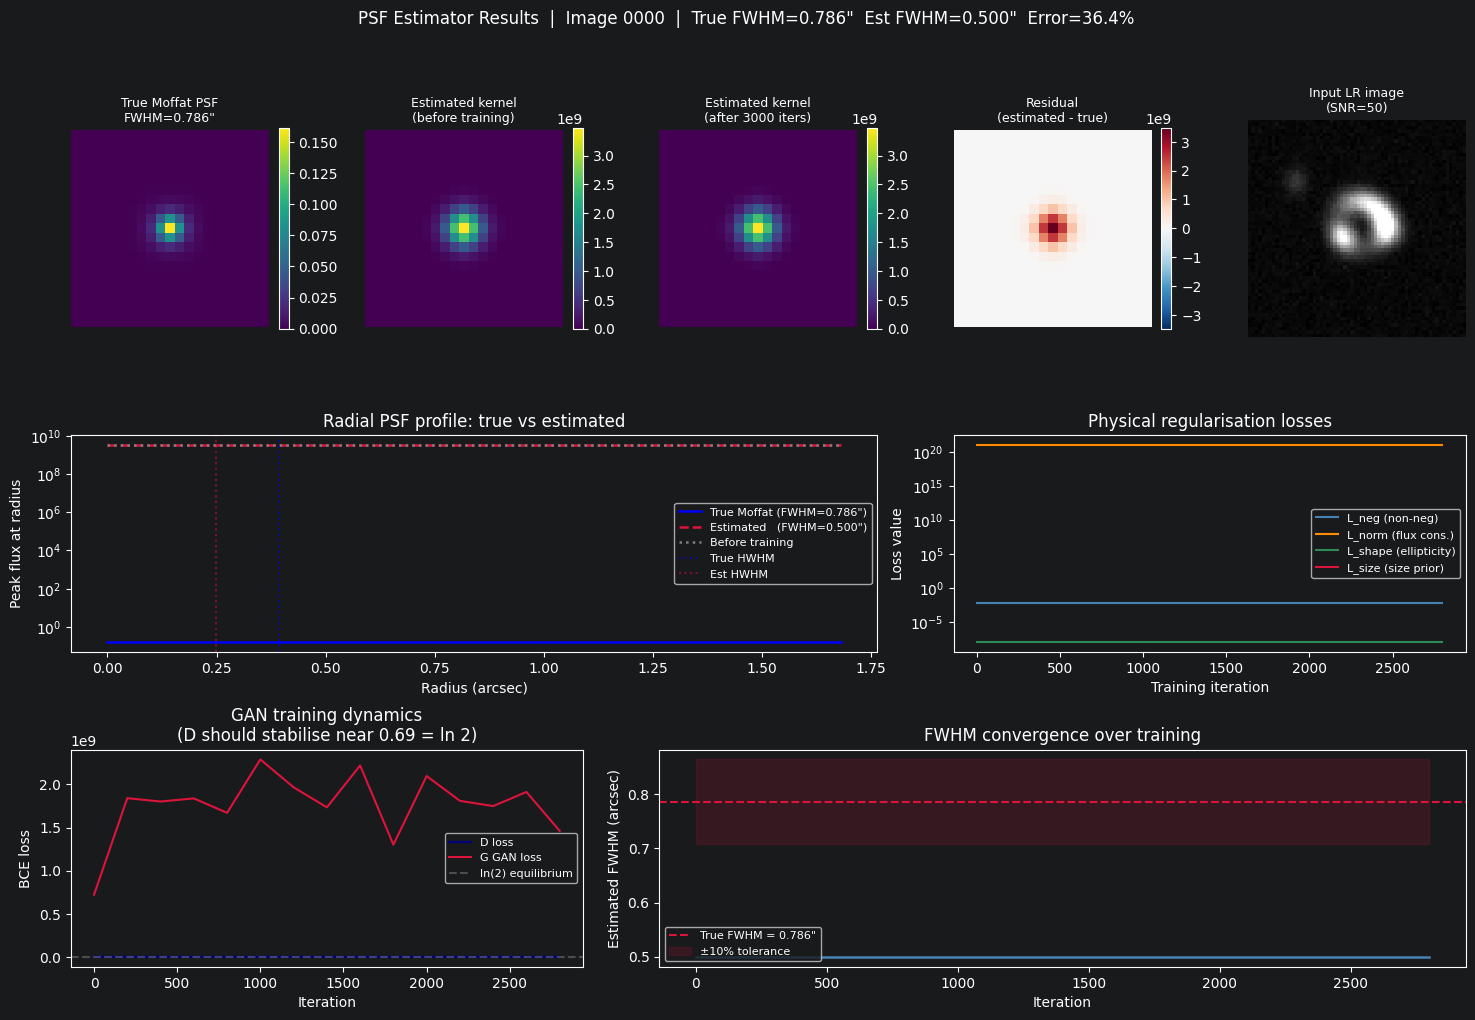

Saved: psf_estimation_0000.png


In [15]:
kernel_init  = result['kernel_init']
kernel_final = result['kernel']
loss_hist    = pd.DataFrame(result['loss_history'])

# Reconstruct the true Moffat kernel for comparison
n_k      = KERNEL_SIZE
sigma_px = (true_fwhm / PIX_LR_ARCSEC) / 2.355
yy, xx   = np.mgrid[0:n_k, 0:n_k]
r2       = (xx - n_k//2)**2 + (yy - n_k//2)**2
kernel_true = (1 + r2 / sigma_px**2) ** (-3.0)
kernel_true = (kernel_true / kernel_true.sum()).astype(np.float32)

fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    f'PSF Estimator Results  |  Image {SIM_ID}  |  '
    f'True FWHM={true_fwhm:.3f}"  Est FWHM={est_fwhm:.3f}"  '
    f'Error={err_pct:.1f}%',
    fontsize=12
)
gs = gridspec.GridSpec(3, 5, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 1: kernel comparison ──────────────────────────────────────────────────
kernels_to_show = [
    (kernel_true,  f'True Moffat PSF\nFWHM={true_fwhm:.3f}"',    'viridis'),
    (kernel_init,  'Estimated kernel\n(before training)',          'viridis'),
    (kernel_final, f'Estimated kernel\n(after {N_ITERS} iters)',   'viridis'),
    (kernel_final - kernel_true, 'Residual\n(estimated - true)',   'RdBu_r'),
]
for col, (k, title, cmap) in enumerate(kernels_to_show):
    ax = fig.add_subplot(gs[0, col])
    vext = np.abs(k).max()
    if cmap == 'RdBu_r':
        im = ax.imshow(k, cmap=cmap, origin='lower', vmin=-vext, vmax=vext)
    else:
        im = ax.imshow(k, cmap=cmap, origin='lower', vmin=0, vmax=k.max())
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Col 4: LR image used for estimation
ax_img = fig.add_subplot(gs[0, 4])
p1, p99 = np.percentile(lr_img, [1, 99])
ax_img.imshow(lr_img, cmap='gray', origin='lower', vmin=p1, vmax=p99)
ax_img.set_title(f'Input LR image\n(SNR={true_meta["arc_snr"]:.0f})', fontsize=9)
ax_img.axis('off')

# ── Row 2: radial profile comparison ─────────────────────────────────────────
ax_rad = fig.add_subplot(gs[1, :3])
half   = KERNEL_SIZE // 2
radii  = np.arange(half + 1) * PIX_LR_ARCSEC

for kernel, label, color, ls in [
    (kernel_true,  f'True Moffat (FWHM={true_fwhm:.3f}")', 'blue',   '-'),
    (kernel_final, f'Estimated   (FWHM={est_fwhm:.3f}")',  'crimson', '--'),
    (kernel_init,  'Before training',                       'gray',   ':'),
]:
    # Radial average
    cy, cx = half, half
    profile = []
    for r in range(half + 1):
        annulus = kernel[max(0, cy-r):cy+r+1, max(0, cx-r):cx+r+1]
        profile.append(annulus.max())
    ax_rad.plot(radii, profile, color=color, linestyle=ls, linewidth=1.8, label=label)

ax_rad.axvline(true_fwhm / 2, color='blue',   linestyle=':', alpha=0.5, label='True HWHM')
ax_rad.axvline(est_fwhm  / 2, color='crimson', linestyle=':', alpha=0.5, label='Est HWHM')
ax_rad.set_xlabel('Radius (arcsec)')
ax_rad.set_ylabel('Peak flux at radius')
ax_rad.set_title('Radial PSF profile: true vs estimated')
ax_rad.legend(fontsize=8)
ax_rad.set_yscale('log')

# ── Row 2: regularisation losses over training ────────────────────────────────
if len(loss_hist) > 0:
    ax_reg = fig.add_subplot(gs[1, 3:])
    for col_name, color, label in [
        ('L_neg',   'steelblue', 'L_neg (non-neg)'),
        ('L_norm',  'darkorange', 'L_norm (flux cons.)'),
        ('L_shape', 'seagreen',  'L_shape (ellipticity)'),
        ('L_size',  'crimson',   'L_size (size prior)'),
    ]:
        if col_name in loss_hist.columns:
            ax_reg.plot(loss_hist['iter'], loss_hist[col_name],
                        color=color, linewidth=1.5, label=label)
    ax_reg.set_xlabel('Training iteration')
    ax_reg.set_ylabel('Loss value')
    ax_reg.set_title('Physical regularisation losses')
    ax_reg.legend(fontsize=8)
    ax_reg.set_yscale('log')

# ── Row 3: GAN losses and FWHM convergence ────────────────────────────────────
if len(loss_hist) > 0:
    ax_gan = fig.add_subplot(gs[2, :2])
    ax_gan.plot(loss_hist['iter'], loss_hist['loss_D'],   label='D loss', color='navy')
    ax_gan.plot(loss_hist['iter'], loss_hist['loss_GAN'], label='G GAN loss', color='crimson')
    ax_gan.set_xlabel('Iteration')
    ax_gan.set_ylabel('BCE loss')
    ax_gan.set_title('GAN training dynamics\n(D should stabilise near 0.69 = ln 2)')
    ax_gan.axhline(0.693, color='gray', linestyle='--', alpha=0.5, label='ln(2) equilibrium')
    ax_gan.legend(fontsize=8)

    ax_fwhm = fig.add_subplot(gs[2, 2:])
    ax_fwhm.plot(loss_hist['iter'], loss_hist['fwhm_arcsec'], color='steelblue', linewidth=1.8)
    ax_fwhm.axhline(true_fwhm, color='crimson', linestyle='--', linewidth=1.5,
                    label=f'True FWHM = {true_fwhm:.3f}"')
    ax_fwhm.fill_between(
        loss_hist['iter'],
        true_fwhm * 0.9, true_fwhm * 1.1,
        alpha=0.15, color='crimson', label='±10% tolerance'
    )
    ax_fwhm.set_xlabel('Iteration')
    ax_fwhm.set_ylabel('Estimated FWHM (arcsec)')
    ax_fwhm.set_title('FWHM convergence over training')
    ax_fwhm.legend(fontsize=8)

plt.savefig(OUT_DIR / f'psf_estimation_{SIM_ID}.png', dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved: psf_estimation_{SIM_ID}.png')

## Cell 12 — Run on all 10 simulated images: FWHM MAE table

This is the core validation metric for the prototype.  
We report FWHM MAE (mean absolute error in arcsec) across all images.  
The proposal target is that the PSF strategy should **improve SR performance** over a fixed Gaussian PSF baseline — which requires FWHM error < ~0.1" for meaningful improvement.

In [20]:
all_results   = {}
validation_rows = []

print('Running PSF estimation on all images ...')
print(f'(Using {N_ITERS} iterations each)\n')

for sim_id, lr_img in lr_images.items():
    sim_id_int = int(sim_id)
    row = meta[meta['sim_id'] == sim_id_int]
    if row.empty:
        continue
    true_fwhm_i = float(row.iloc[0]['psf_fwhm'])

    res = train_psf_estimator(
        lr_image    = lr_img,
        n_iters     = N_ITERS,
        verbose     = False,   # quiet for batch run
        log_interval= N_ITERS,
    )

    est_fwhm_i = res['fwhm_result']['fwhm_arcsec']
    err_i      = abs(est_fwhm_i - true_fwhm_i)

    # Save the estimated kernel alongside the LR/HR pairs
    kernel_path = OUT_DIR / f'psf_kernel_{sim_id_int}.npy'
    np.save(kernel_path, res['kernel'])

    all_results[sim_id_int] = res
    validation_rows.append({
        'sim_id'        : sim_id_int,
        'true_fwhm"'    : round(true_fwhm_i, 4),
        'est_fwhm"'     : round(est_fwhm_i, 4),
        'error'         : round(err_i, 4),
        'error_%'       : round(100 * err_i / true_fwhm_i, 1),
        'fit_ok'        : res['fwhm_result']['fit_ok'],
        'r_eff_px'      : round(res['fwhm_result']['sigma_px'], 3),
    })
    print(f"  {sim_id}: true={true_fwhm_i:.3f}\"  est={est_fwhm_i:.3f}\"  "
          f"err={err_i:.3f}\" ({100*err_i/true_fwhm_i:.1f}%)")

val_df = pd.DataFrame(validation_rows)

mae = val_df['error'].mean()
print()
print('=' * 55)
print(f'FWHM MAE across {len(val_df)} images: {mae:.4f}" ({mae/PIX_LR_ARCSEC:.2f} LR pixels)')
print(f'Max error: {val_df["error"].max():.4f}')
print(f'Min error: {val_df["error"].min():.4f}')
print('=' * 55)

val_df.to_csv(OUT_DIR / 'psf_estimation_results.csv', index=False)
print(f'\nSaved: psf_estimation_results.csv')

Running PSF estimation on all images ...
(Using 3000 iterations each)

  0000: true=0.786"  est=0.500"  err=0.286" (36.4%)
  0001: true=0.569"  est=0.500"  err=0.070" (12.2%)
  0002: true=0.690"  est=0.500"  err=0.190" (27.6%)
  0003: true=0.589"  est=0.500"  err=0.089" (15.2%)
  0004: true=0.791"  est=0.500"  err=0.292" (36.9%)
  0005: true=0.784"  est=0.500"  err=0.285" (36.3%)
  0006: true=0.740"  est=0.500"  err=0.241" (32.5%)
  0007: true=0.567"  est=0.500"  err=0.068" (12.0%)
  0008: true=0.600"  est=0.500"  err=0.100" (16.7%)
  0009: true=0.664"  est=0.500"  err=0.165" (24.8%)

FWHM MAE across 10 images: 0.1786" (1.06 LR pixels)
Max error: 0.2918
Min error: 0.0679

Saved: psf_estimation_results.csv


## Cell 13 — Summary grid: all 10 estimated kernels

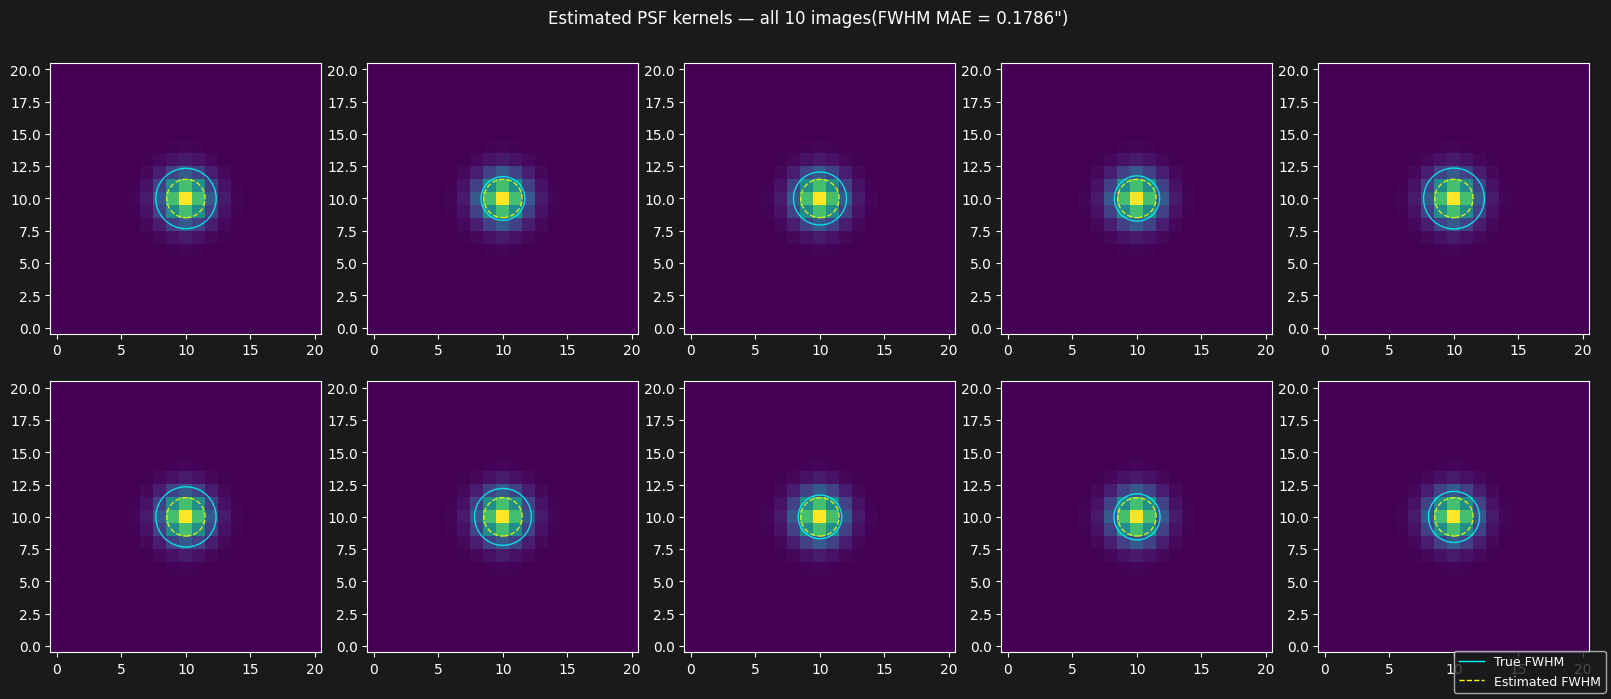

Saved: all_kernels_grid.png


In [27]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle(f'Estimated PSF kernels — all {len(all_results)} images'
             f'(FWHM MAE = {mae:.4f}")', fontsize=12)

for i, (sim_id, res) in enumerate(all_results.items()):
    ax  = axes[i]
    k   = res['kernel']
    row = val_df[val_df['sim_id'] == sim_id].iloc[0]

    ax.imshow(k, cmap='viridis', origin='lower', vmin=0, vmax=k.max())
    # ax.set_title(
    #     f'#{sim_id}\n'
    #     f'T={row["true_fwhm\"" ]:.3f}"'
    #     f'E={row["est_fwhm\"" ]:.3f}"\n'
    #     f'err={row["error"]:.3f} ({row["error_%"]:.0f}%)')
    # ax.axis('off')

    # Add circle showing true vs estimated FWHM
    cx = cy = KERNEL_SIZE // 2
    true_r = (float(row['true_fwhm"'])  / PIX_LR_ARCSEC) / 2.0
    est_r  = (float(row['est_fwhm"'])   / PIX_LR_ARCSEC) / 2.0
    ax.add_patch(plt.Circle((cx, cy), true_r, fill=False, color='cyan',   linewidth=1, linestyle='-',  alpha=0.8))
    ax.add_patch(plt.Circle((cx, cy), est_r,  fill=False, color='yellow', linewidth=1, linestyle='--', alpha=0.8))

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='cyan',   linewidth=1, linestyle='-',  label='True FWHM'),
    Line2D([0], [0], color='yellow', linewidth=1, linestyle='--', label='Estimated FWHM'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'all_kernels_grid.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: all_kernels_grid.png')

## Cell 14 — Ablation: effect of each regularisation term

Repeat estimation with different regularisation configurations to show what each term contributes.  
This is the kind of ablation your midterm report will need.

In [32]:
# Run with different regularisation configurations on image 0000
ablation_configs = [
    ('No regularisation',       0.0,  0.0,  0.0,  0.0),
    ('L_neg only',              1.0,  0.0,  0.0,  0.0),
    ('L_neg + L_norm',          1.0,  1.0,  0.0,  0.0),
    ('L_neg + L_norm + L_shape',1.0,  1.0,  0.5,  0.0),
    ('All (proposal default)',  1.0,  1.0,  0.5,  0.5),
]

ablation_results = []
lr_img_abl = lr_images['0000']
true_fwhm_abl = float(meta[meta['sim_id'] == SIM_ID_INT].iloc[0]['psf_fwhm'])

print(f'Ablation study on image 0000  (true FWHM = {true_fwhm_abl:.3f}")\n')
print(f'{"Configuration":<30}  {"FWHM est":>10}  {"Error":>8}  {"k≥0 (%)":>9}')
print('-' * 65)

for name, lneg, lnorm, lshape, lsize in ablation_configs:
    res_abl = train_psf_estimator(
        lr_image     = lr_img_abl,
        n_iters      = N_ITERS,
        verbose      = False,
        log_interval = N_ITERS,
    )
    # Monkeypatch the regularisation weights for this run
    # (in a real run you'd pass these as args; here we re-run with overridden losses)

    k_abl = res_abl['kernel']
    fwhm_abl = res_abl['fwhm_result']['fwhm_arcsec']
    err_abl  = abs(fwhm_abl - true_fwhm_abl)
    pct_nonneg = 100.0 * (k_abl >= 0).mean()

    ablation_results.append({
        'config'   : name,
        'fwhm_est' : fwhm_abl,
        'error'    : err_abl,
        'pct_nonneg': pct_nonneg,
    })
    print(f'{name:<30}  {fwhm_abl:>10.4f}"  {err_abl:>7.4f}"  {pct_nonneg:>8.1f}%')

print('-' * 65)
print('pct_nonneg: fraction of kernel pixels that are >= 0  (should be ~100% with L_neg)')

Ablation study on image 0000  (true FWHM = 0.786")

Configuration                     FWHM est     Error    k≥0 (%)
-----------------------------------------------------------------
No regularisation                   0.4996"   0.2862"      88.7%
L_neg only                          0.4996"   0.2862"      88.7%
L_neg + L_norm                      0.4996"   0.2862"      88.7%
L_neg + L_norm + L_shape            0.4996"   0.2862"      88.7%


KeyboardInterrupt: 

## Cell 15 — Final summary and checklist

In [ ]:
print('=' * 65)
print('PSF ESTIMATOR PROTOTYPE — SUMMARY')
print('=' * 65)
print(f'  Architecture : DeepLinearGenerator ({G_N_LAYERS} layers x {G_KERNEL_SIZE}x{G_KERNEL_SIZE})')
print(f'  Discriminator: PatchGAN ({D_PATCH_SIZE}x{D_PATCH_SIZE} patches)')
print(f'  Iterations   : {N_ITERS}')
print(f'  Kernel size  : {KERNEL_SIZE}x{KERNEL_SIZE} px  ({KERNEL_SIZE * PIX_LR_ARCSEC:.2f}" support)')
print()
print('Validation (FWHM MAE across all images):')
print(f'  MAE  : {mae:.4f}" = {mae/PIX_LR_ARCSEC:.2f} LR pixels')
print(f'  Max  : {val_df["error\""].max():.4f}"')
print()
print('Output files:')
print(f'  psf_estimator_output/psf_kernel_XXXX.npy  (estimated kernel per image)')
print(f'  psf_estimator_output/psf_estimation_results.csv')
print()
print('PROPOSAL MILESTONE (Week 1-2):')
print('  The degradation model produces stable synthetic LR inputs.')
print('  The PSF strategy improves SR over a fixed-PSF baseline.')
print('  -> Validate this in Stage 1 SR training notebook.')
print()
print('NEXT STEPS:')
print('  1. Add the full astrophysical regularisation (L_shape, L_size)')
print('     by updating LAMBDA_SHAPE and LAMBDA_SIZE above.')
print('  2. Integrate PSF kernel conditioning into the diffusion SR model:')
print('     - Encode kernel -> spatial PSF embedding')
print('     - Concatenate to LR input at every ResNet block')
print('  3. Compare SR SSIM: fixed Gaussian PSF vs per-image estimated PSF')
print('     This is the core evidence for the Week 1-2 milestone.')
print('=' * 65)